# [1] Imports & Setup (Dual Run Modes) — Modular Version

In [1]:
import os
import sys
from pathlib import Path
import numpy as np

# Setup path to include repository and eMach roots
repo_root = Path.cwd().resolve()
while repo_root.name and repo_root.name not in ("EveryMotor", "NvidiaNemo"):
    repo_root = repo_root.parent
emach_root = repo_root / "eMach"
if str(emach_root) not in sys.path:
    sys.path.insert(0, str(emach_root))
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repository Root: {repo_root}")
print(f"eMach Root: {emach_root}")

from jeet_acloss_rbf import (
    AcLossJsonReader,
    RbfModelBuilder,
    AcLossEvaluator,
    AcLossPlotter
)

Repository Root: D:\KangDH\EveryMotor
eMach Root: D:\KangDH\EveryMotor\eMach


# [2] Motor Model & Run Mode Configuration

In [9]:
MOTOR_FILES = {
    'Ref': r"D:\KangDH\Thesis\e10\refModel\e10Turn6V261.mot",
    'HalfSC': r"D:\KangDH\Thesis\e10\SLFEA_Half\e10Turn6V261SLFEA_Half_2.mot",
    'SC': r"D:\KangDH\Thesis\e10\SLFEA\e10Turn6V261SLFEA.mot"
}
json_summary_path = Path(r"D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\SC\JEET_ACLoss_SC_Map_Summary.json")
out_dir = json_summary_path.parent
MODEL_SCALE = 'SC'  # Options: 'Ref', 'HalfSC', 'SC'
RUN_FEA_SWEEP = True  # True: Run FEA inside Motor-CAD. False: Bypasses connection, loads JSON map only.

In [10]:
print("=== [Data & Model Path Existence Check] ===")
for scale in ['Ref', 'HalfSC', 'SC']:
    mot_p = MOTOR_FILES.get(scale)
    json_p = out_dir.parent / scale / f"JEET_ACLoss_{scale}_Map_Summary.json"
    
    mot_exists = Path(mot_p).exists() if mot_p else False
    json_exists = json_p.exists()
    
    print(f"[{scale}]")
    print(f"  - .mot file path: {mot_p}")
    print(f"    -> Exists? {'[YES]' if mot_exists else '[NO]'}")
    print(f"  - JSON summary:  {json_p}")
    print(f"    -> Exists? {'[YES]' if json_exists else '[NO]'}")
print("===========================================\n")

mot_file_path = MOTOR_FILES.get(MODEL_SCALE)
print(f"Selected Model Scale: {MODEL_SCALE}")
print(f"Target Motor File: {mot_file_path}")
print(f"FEA Sweep Execution: {'ENABLED' if RUN_FEA_SWEEP else 'DISABLED (Offline Mode)'}")

# Output summary paths
# json_summary_path = out_dir.parent / MODEL_SCALE / f"JEET_ACLoss_{MODEL_SCALE}_Map_Summary.json"
mat_summary_path = out_dir.parent / MODEL_SCALE / f"JEET_ACLoss_{MODEL_SCALE}_Map_Summary.mat"
rbf_model_path = out_dir.parent / MODEL_SCALE / f"AF_RBF_model_{MODEL_SCALE}.json"

COND_WIDTH_MM, COND_HEIGHT_MM, ACTIVE_LENGTH_MM = 2.5, 2.5, 150.0

mcad = None
if RUN_FEA_SWEEP:
    print("Connecting to Motor-CAD instance...")
    try:
        import ansys.motorcad.core as pymotorcad
        mcad = pymotorcad.MotorCAD(open_new_instance=False)
        if Path(mot_file_path).exists():
            print(f"Loading selected model: {mot_file_path}")
            mcad.load_from_file(mot_file_path)
        else:
            print(f"[WARN] Motor-CAD file not found at: {mot_file_path}")
            print("Will attempt to proceed with the currently active Motor-CAD model.")
        COND_WIDTH_MM = float(mcad.get_variable("Copper_Width"))
        COND_HEIGHT_MM = float(mcad.get_variable("Copper_Height"))
        ACTIVE_LENGTH_MM = float(mcad.get_variable("Stator_Lam_Length"))
        print(f"✓ Read parameters: Width={COND_WIDTH_MM:.2f}mm, Height={COND_HEIGHT_MM:.2f}mm, Length={ACTIVE_LENGTH_MM:.1f}mm")
    except Exception as e:
        print(f"[WARN] Motor-CAD connection/read failed: {e}")
else:
    print("[Offline Mode] Motor-CAD connection bypassed.")
    print(f"Using default fallback parameters: Width={COND_WIDTH_MM}mm, Height={COND_HEIGHT_MM}mm, Length={ACTIVE_LENGTH_MM}mm")

b_m = COND_WIDTH_MM * 1e-3
h_m = COND_HEIGHT_MM * 1e-3
L_a = ACTIVE_LENGTH_MM * 1e-3

POLE_PAIRS = 4
def speed_to_fe(speed_rpm, pole_pairs=POLE_PAIRS):
    return pole_pairs * speed_rpm / 60.0

# JSON status print
from collections import Counter as _Counter
if json_summary_path.exists():
    try:
        with open(json_summary_path, 'r', encoding='utf-8') as _f:
            _loaded = json.load(_f)
        _records  = _loaded.get('records', _loaded) if isinstance(_loaded, dict) else _loaded
        _meta     = _loaded.get('_meta', {})        if isinstance(_loaded, dict) else {}
        print(f"[JSON 현황: {MODEL_SCALE}]  총 {len(_records)}개 레코드")
        if _meta:
            print(f"  저장된 sweep 범위:")
            print(f"    PROXIMITY_MODELS  : {_meta.get('proximity_models', '?')}")
            print(f"    SPEEDS            : {_meta.get('speeds', '?')}")
            print(f"    CURRENT_GRID 크기 : {_meta.get('n_curr_design', '?')} pts  ({_meta.get('design_2d_strategy', '?')})")
            print(f"    PHASE_GRID 크기   : {_meta.get('n_phase_design', '?')} pts")
            print(f"    총 스케줄 포인트   : {_meta.get('total_schedule', '?')}")
            print(f"    마지막 갱신       : {_meta.get('last_updated', '?')}")
        if _records:
            _cnt = _Counter((r.get('proximity_model'), r.get('speed')) for r in _records)
            _labels = {1: 'Hybrid', 3: 'FullFEA'}
            print("  완료 현황 (모델 x 속도):")
            for (pm, spd), n in sorted(_cnt.items()):
                _has_result = sum(
                    1 for r in _records
                    if r.get('proximity_model') == pm and r.get('speed') == spd
                    and (('hybrid_total_kW' in r) if pm == 1 else ('fea_total_ac_kW' in r))
                )
                print(f"    [{_labels.get(pm, pm)}] {spd}RPM : {_has_result}/{n} 유효")
    except Exception as _e:
        print(f"  [WARN] JSON 파싱 실패: {_e}")

=== [Data & Model Path Existence Check] ===
[Ref]
  - .mot file path: D:\KangDH\Thesis\e10\refModel\e10Turn6V261.mot
    -> Exists? [YES]
  - JSON summary:  D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\JEET_ACLoss_Ref_Map_Summary.json
    -> Exists? [YES]
[HalfSC]
  - .mot file path: D:\KangDH\Thesis\e10\SLFEA_Half\e10Turn6V261SLFEA_Half_2.mot
    -> Exists? [YES]
  - JSON summary:  D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\HalfSC\JEET_ACLoss_HalfSC_Map_Summary.json
    -> Exists? [YES]
[SC]
  - .mot file path: D:\KangDH\Thesis\e10\SLFEA\e10Turn6V261SLFEA.mot
    -> Exists? [YES]
  - JSON summary:  D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\SC\JEET_ACLoss_SC_Map_Summary.json
    -> Exists? [YES]

Selected Model Scale: SC
Target Motor File: D:\KangDH\Thesis\e10\SLFEA\e10Turn6V261SLFEA.mot
FEA Sweep Execution: ENABLED
Connecting to Motor-CAD instance...
Loading selected model: D:\KangDH\Thesis\e10\SLFEA\e10Turn6V261SLFEA.mot
✓ Read parameters: Width=7.

In [11]:
SIGMA_CU = 5.8e7
MU_0 = 4.0 * np.pi * 1e-7

# [4] id-iq Plane AC Active-Only Loss Surface (per speed)

--- Matplotlib Backend Config ---
  [Selection] 'auto' -> 'widget'
  [OK] Model scale check: verified all 239 records belong to SC


d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:198: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:198: UserWarning: Glyph 47215 (\N{HANGUL SYLLABLE ROS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:198: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:198: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:198: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.

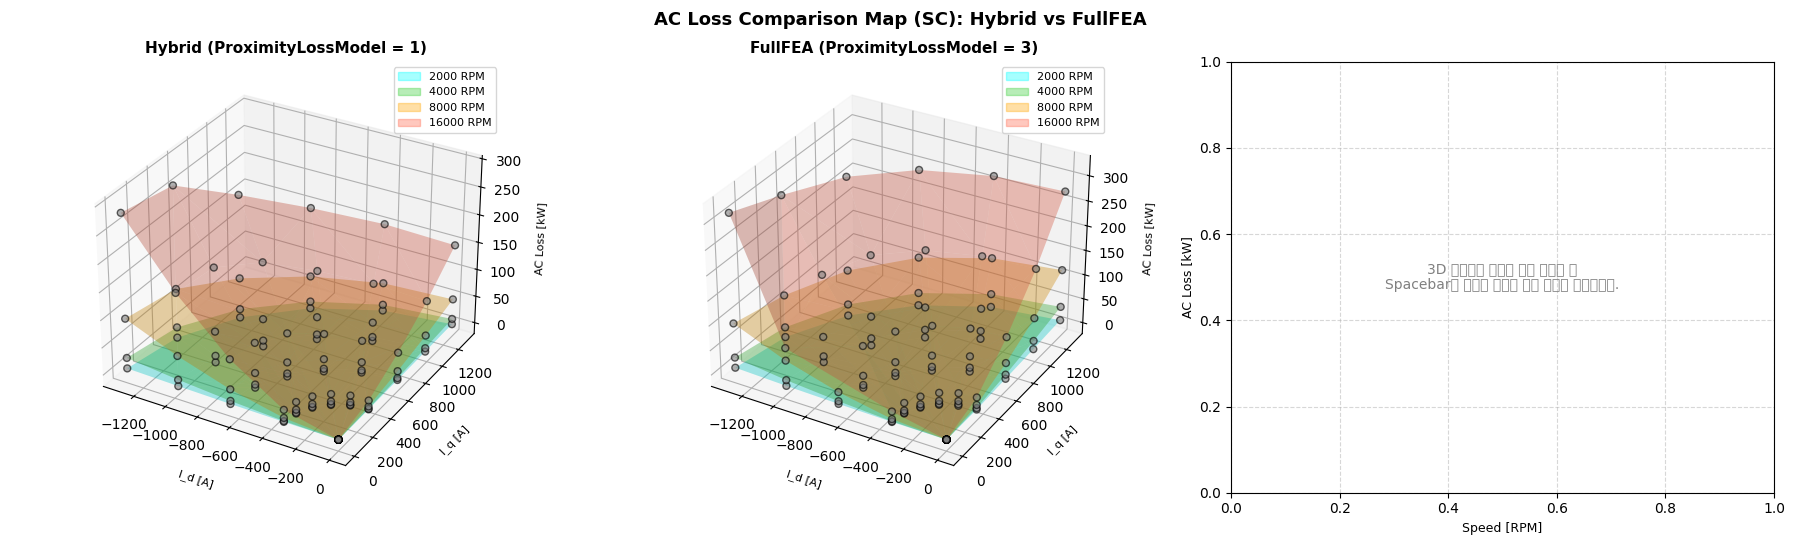

In [12]:
# Select matplotlib backend (auto/inline/widget)
AcLossPlotter.configure_matplotlib_backend('auto')

raw_records, err_code = AcLossJsonReader.read(str(json_summary_path), MODEL_SCALE)
if err_code is None:
    AcLossPlotter.plot_interactive_comparison(raw_records, MODEL_SCALE)
else:
    print(f"Failed to read dataset: {err_code}")

# [5] Adjustment Factor (AF) Modeling

In [13]:
# Load and match dataset
raw_records, err_code = AcLossJsonReader.read(str(json_summary_path), MODEL_SCALE)
if err_code is not None:
    raise RuntimeError(f"Failed to load JSON summary data: {err_code}")

dataset = RbfModelBuilder.match_records_and_create_dataset(raw_records)

  [OK] Model scale check: verified all 239 records belong to SC

[누락 포인트 진단]
  2000RPM  AF 필터 제거 12건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0), (230.1, 0.0), (230.1, 18.0), (460.1, 0.0), (690.0, 0.0), (920.0, 0.0), (920.0, 18.0)]
  4000RPM  AF 필터 제거 7건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0), (920.0, 0.0)]
  8000RPM  AF 필터 제거 6건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0)]
  16000RPM  FEA 미완료 1건: [(460.1, 90.0)]
  16000RPM  AF 필터 제거 6건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0)]
AF 매칭 계산 완료: 88개 운전점
AF 범위: min=0.4744,  max=2.9032,  mean=1.4907


# [5.5] Method B: RBF Model Build (3D TPS RBF vs. 1D×2D Separable RBF)

In [14]:
# Fit RBF models
model_3d = RbfModelBuilder.build_3d_rbf(dataset)
model_sep = RbfModelBuilder.build_separable_rbf(dataset)

print("\n  model_3d_rbf() 및 model_sep_rbf() 수립 완료 (Separable 기본 활성화)")

  f( 2000 RPM): n=1  mean=1.0000  range=[1.0000, 1.0000]
  f( 4000 RPM): n=2  mean=1.2089  range=[1.0434, 1.3744]
  f( 8000 RPM): n=2  mean=0.9464  range=[0.8083, 1.0845]
  f(16000 RPM): n=2  mean=0.8199  range=[0.6738, 0.9661]

  model_3d_rbf() 및 model_sep_rbf() 수립 완료 (Separable 기본 활성화)


# [6] Method A: Speed-Only Quadratic Polynomial + AF vs Speed Visualization

=== 방법 A: 속도만의 2차 다항식 (최대 전류 기준) ===
  I_rms = 920.0 A 기준
  AF(s) = 0.001094·s² -0.047012·s +1.880838   (s: kRPM)

    2 kRPM: AF_ref=2.604, AF_fit=1.791, Δ=-0.812
    2 kRPM: AF_ref=1.877, AF_fit=1.791, Δ=-0.086
    2 kRPM: AF_ref=1.295, AF_fit=1.791, Δ=+0.496
    2 kRPM: AF_ref=1.329, AF_fit=1.791, Δ=+0.463
    4 kRPM: AF_ref=2.646, AF_fit=1.710, Δ=-0.936
    4 kRPM: AF_ref=2.169, AF_fit=1.710, Δ=-0.459
    4 kRPM: AF_ref=1.589, AF_fit=1.710, Δ=+0.121
    4 kRPM: AF_ref=1.113, AF_fit=1.710, Δ=+0.597
    4 kRPM: AF_ref=1.140, AF_fit=1.710, Δ=+0.571
    8 kRPM: AF_ref=1.719, AF_fit=1.575, Δ=-0.144
    8 kRPM: AF_ref=2.320, AF_fit=1.575, Δ=-0.746
    8 kRPM: AF_ref=2.052, AF_fit=1.575, Δ=-0.477
    8 kRPM: AF_ref=1.316, AF_fit=1.575, Δ=+0.259
    8 kRPM: AF_ref=0.975, AF_fit=1.575, Δ=+0.600
    8 kRPM: AF_ref=1.013, AF_fit=1.575, Δ=+0.561
    16 kRPM: AF_ref=1.829, AF_fit=1.409, Δ=-0.421
    16 kRPM: AF_ref=1.698, AF_fit=1.409, Δ=-0.289
    16 kRPM: AF_ref=1.511, AF_fit=1.409, Δ=-0.102


d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:253: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:253: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:253: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:253: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:255: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=150, bbox_inches='tight')
d:\KangDH\EveryMotor\eMach\mlxperPJ

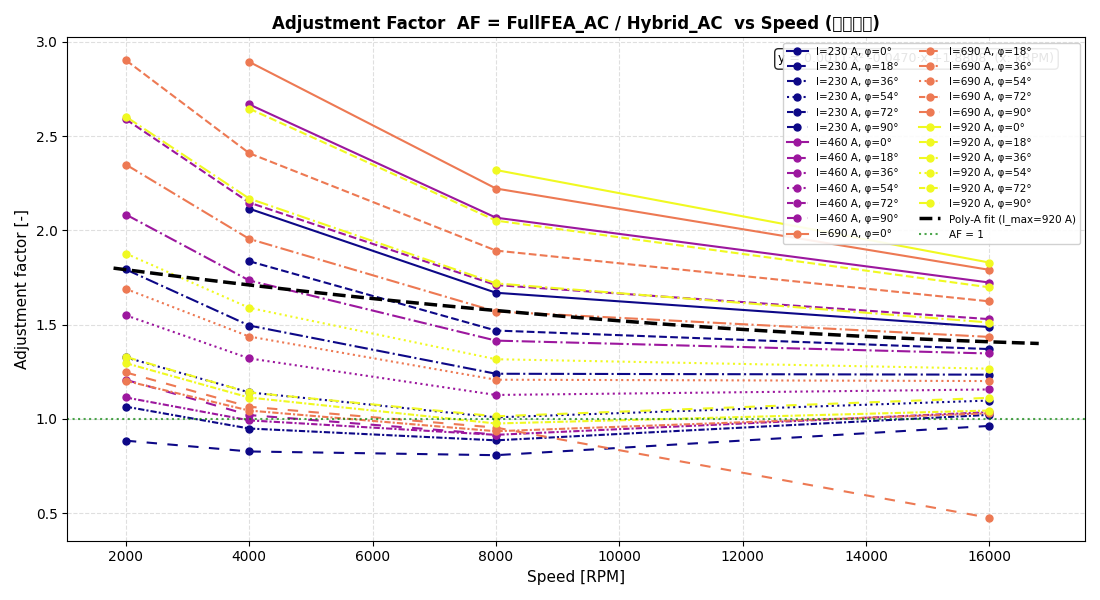

저장: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\SC\AF_vs_speed_curves.png


In [15]:
coeffs_A, max_curr = AcLossEvaluator.fit_method_a(dataset)

print("=== 방법 A: 속도만의 2차 다항식 (최대 전류 기준) ===")
print(f"  I_rms = {max_curr:.1f} A 기준")
a2, a1, a0 = coeffs_A
print(f"  AF(s) = {a2:.6f}·s² {a1:+.6f}·s {a0:+.6f}   (s: kRPM)\n")

mask_maxcurr = np.isclose(dataset.irms_arr, max_curr, rtol=0.01)
spd_mc = dataset.speeds_k[mask_maxcurr]
af_mc = dataset.af_arr[mask_maxcurr]
sort_idx = np.argsort(spd_mc)
spd_mc, af_mc = spd_mc[sort_idx], af_mc[sort_idx]
af_A_fit = np.polyval(coeffs_A, spd_mc)
for s, ref, fit in zip(spd_mc, af_mc, af_A_fit):
    print(f"    {s:.0f} kRPM: AF_ref={ref:.3f}, AF_fit={fit:.3f}, Δ={fit-ref:+.3f}")
    
lab_formula_extra = f"(({a2:.6f}*(Speed/1000)^2 + {a1:.6f}*(Speed/1000) + {a0:.6f}) - 1) * Stator_Copper_Loss_AC"
print(f"\n  [Motor-CAD Lab 수식]\n  {lab_formula_extra}")

AcLossPlotter.plot_af_vs_speed_curves(dataset, coeffs_A, max_curr, out_dir / "AF_vs_speed_curves.png")

# [6.5 + 8] AF Distribution on id-iq Plane & Ablation Study

In [ ]:
# Plot AF contour map visualization
AcLossPlotter.plot_af_map_visualization(dataset, model_sep, out_dir / "AF_map_visualization.png")


=== 3D TPS RBF Ablation  (n_centers = [4, 8, 12, 16, 20, 24, 28, 32, 40, 50, 60, 80, 88]) ===
  n=  4: Train=0.00+/-0.00%  Held-out=581.86+/-892.02%
  n=  8: Train=0.00+/-0.00%  Held-out=218.99+/-179.35%
  n= 12: Train=0.00+/-0.00%  Held-out=136.87+/-199.33%
  n= 16: Train=0.00+/-0.00%  Held-out=38.75+/-36.03%
  n= 20: Train=0.00+/-0.00%  Held-out=18.72+/-5.79%
  n= 24: Train=0.00+/-0.00%  Held-out=12.31+/-4.38%
  n= 28: Train=0.00+/-0.00%  Held-out=9.25+/-2.30%
  n= 32: Train=0.00+/-0.00%  Held-out=8.46+/-2.74%
  n= 40: Train=0.00+/-0.00%  Held-out=6.96+/-1.57%
  n= 50: Train=0.00+/-0.00%  Held-out=6.10+/-1.07%
  n= 60: Train=0.00+/-0.00%  Held-out=5.68+/-1.44%
  n= 80: Train=0.00+/-0.00%  Held-out=4.90+/-3.30%
  n= 88: Train=0.00+/-0.00%  Held-out=3.50+/-3.79%

=== Separable RBF Ablation  n_base=[4, 6, 8, 10, 12, 16, 20, 24, 30] x n_spd/spd=[1, 2, 3, 4, 6, 8] ===
  n_base= 4: ns=1->862.36%  ns=2->825.57%  ns=3->767.69%  ns=4->710.76%  ns=6->711.28%  ns=8->729.98%  
  n_base= 6: ns=1

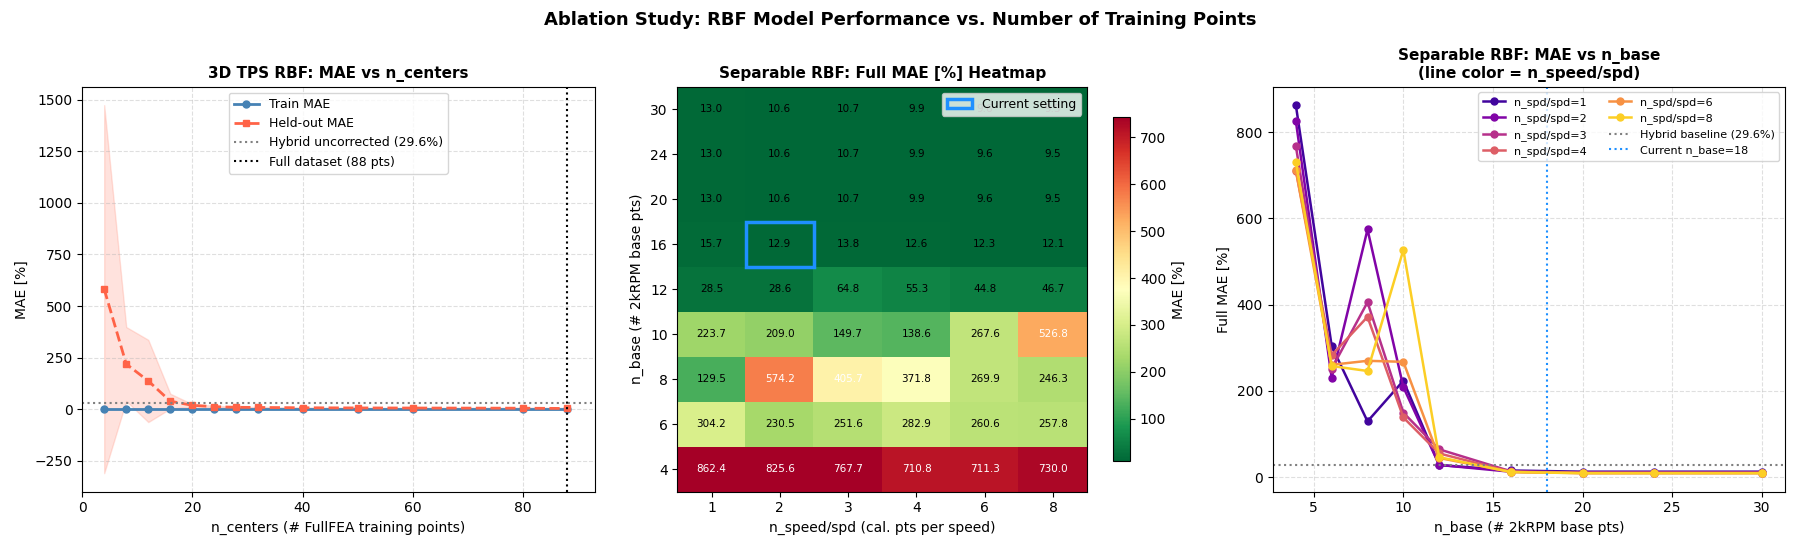

Saved: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\SC\ablation_study_SC.png

=== Summary: 3D RBF Held-out MAE vs n_centers ===
  n=  4: 581.86 +/- 892.02%
  n=  8: 218.99 +/- 179.35%
  n= 12: 136.87 +/- 199.33%
  n= 16: 38.75 +/- 36.03%
  n= 20: 18.72 +/- 5.79%
  n= 24: 12.31 +/- 4.38%
  n= 28: 9.25 +/- 2.30%
  n= 32: 8.46 +/- 2.74%
  n= 40: 6.96 +/- 1.57%
  n= 50: 6.10 +/- 1.07%
  n= 60: 5.68 +/- 1.44%
  n= 80: 4.90 +/- 3.30%
  n= 88: 3.50 +/- 3.79% <- current (full)

=== Summary: Separable RBF ===
  Best:    n_base=20, n_spd=8 -> MAE=9.52%
  Current: n_base=18, n_spd=2 -> MAE=12.86%


In [16]:
# Run Ablation Study
n_center_list = sorted(set([4, 8, 12, 16, 20, 24, 28, 32, 40, 50, 60, 80, len(dataset)]))
print(f"\n=== 3D TPS RBF Ablation  (n_centers = {n_center_list}) ===")
res_3d_tr_m, res_3d_tr_s, res_3d_te_m, res_3d_te_s = AcLossEvaluator.run_ablation_study_3d(dataset, n_center_list)
for i, nc in enumerate(n_center_list):
    print(f"  n={nc:3d}: Train={res_3d_tr_m[i]:.2f}+/-{res_3d_tr_s[i]:.2f}%  "
          f"Held-out={res_3d_te_m[i]:.2f}+/-{res_3d_te_s[i]:.2f}%")

n_base_list = [4, 6, 8, 10, 12, 16, 20, 24, 30]
n_speed_list = [1, 2, 3, 4, 6, 8]
print(f"\n=== Separable RBF Ablation  n_base={n_base_list} x n_spd/spd={n_speed_list} ===")
res_sep = AcLossEvaluator.run_ablation_study_separable(dataset, n_base_list, n_speed_list)
for bi, nb in enumerate(n_base_list):
    row_str = f"  n_base={nb:2d}: "
    for si, ns in enumerate(n_speed_list):
        row_str += f"ns={ns}->{res_sep[bi, si]:.2f}%  "
    print(row_str)

# Find length of base index and current separable n_spd settings
base_idx = np.where(np.abs(dataset.speeds_k - 2.0) < 0.1)[0]
other_speeds = [4.0, 8.0, 16.0]
target_currents = [115.0, 230.0, 345.0, 460.0]
selected_other_idx = []
for spd in other_speeds:
    spd_idx = np.where(np.abs(dataset.speeds_k - spd) < 0.1)[0]
    for i_val in target_currents:
        _phase_mask = dataset.phase_arr[spd_idx] < 85.0
        _valid_idx = spd_idx[_phase_mask] if _phase_mask.any() else spd_idx
        diffs = (dataset.irms_arr[_valid_idx] - i_val)**2
        best_idx = _valid_idx[np.argmin(diffs)]
        selected_other_idx.append(best_idx)
selected_other_idx = np.unique(selected_other_idx)

n_base_len = len(base_idx)
n_spd_len = len(selected_other_idx) // len(other_speeds)

AcLossPlotter.plot_ablation_study(
    dataset, n_center_list,
    res_3d_tr_m, res_3d_tr_s, res_3d_te_m, res_3d_te_s,
    res_sep, n_base_list, n_speed_list,
    n_base_len, n_spd_len,
    out_dir / f"ablation_study_{MODEL_SCALE}.png"
)

print("\n=== Summary: 3D RBF Held-out MAE vs n_centers ===")
for i, nc in enumerate(n_center_list):
    marker = " <- current (full)" if nc == len(dataset) else ""
    print(f"  n={nc:3d}: {res_3d_te_m[i]:.2f} +/- {res_3d_te_s[i]:.2f}%{marker}")

best_bi, best_si = np.unravel_index(np.nanargmin(res_sep), res_sep.shape)
print(f"\n=== Summary: Separable RBF ===")
print(f"  Best:    n_base={n_base_list[best_bi]}, n_spd={n_speed_list[best_si]} -> MAE={res_sep[best_bi, best_si]:.2f}%")
cur_nb_idx = min(range(len(n_base_list)), key=lambda i: abs(n_base_list[i] - n_base_len))
cur_ns_idx = min(range(len(n_speed_list)), key=lambda i: abs(n_speed_list[i] - n_spd_len))
print(f"  Current: n_base={n_base_len}, n_spd={n_spd_len} -> MAE={res_sep[cur_nb_idx, cur_ns_idx]:.2f}%")

# [9] Exhaustive Calibration-Point Search (n_spd/spd = 1)

완료  |  MAE 범위: 8.59% ~ 41.03%  (평균 12.69%)


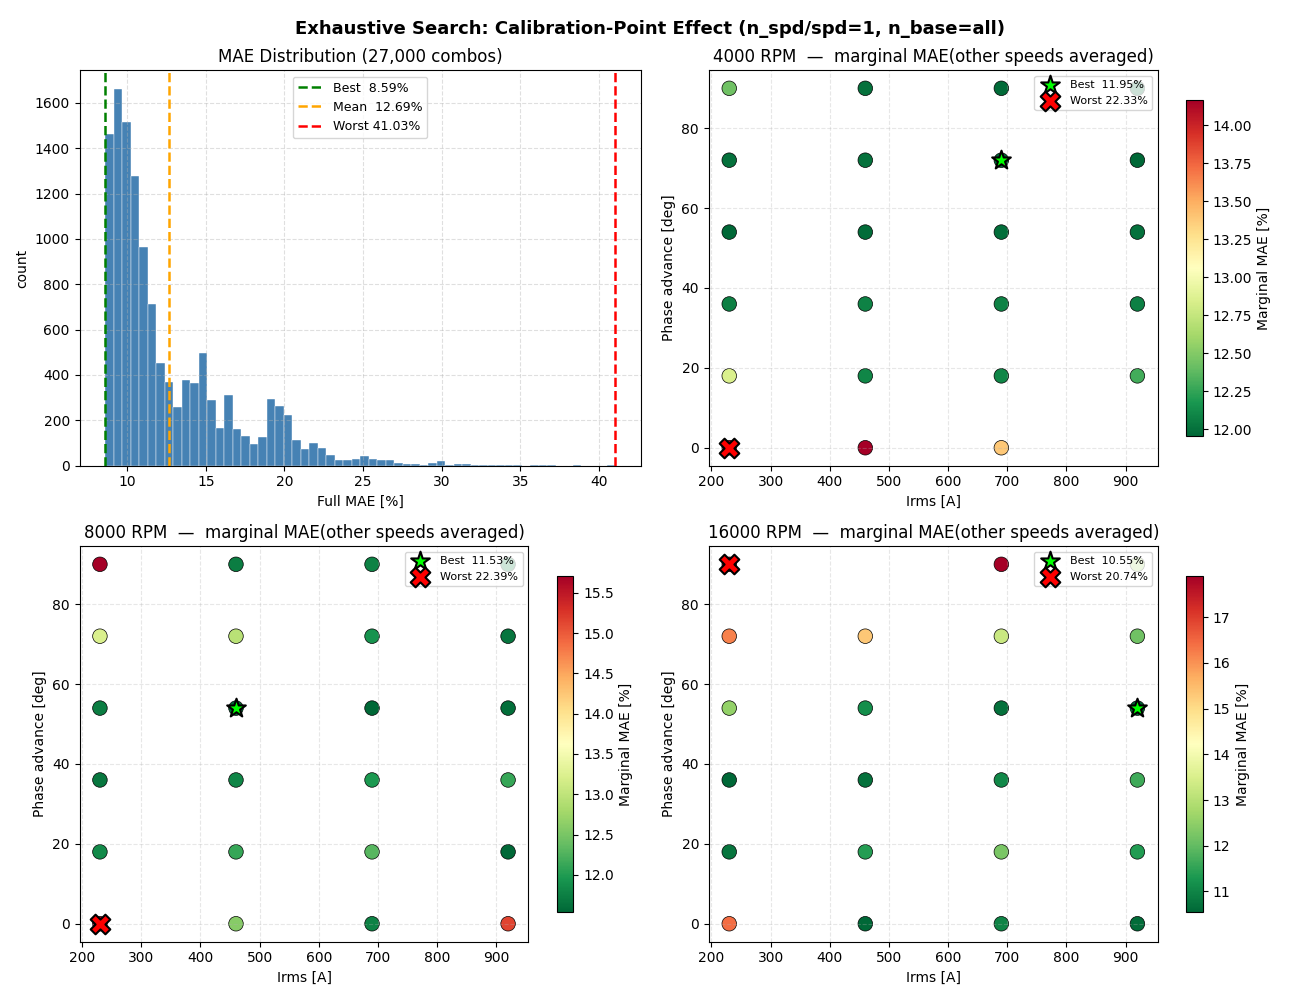

저장: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\SC\exhaustive_cal_search_SC.png
=== Best combination ===
  4000 RPM: Irms=460.1 A  phase=72.0 deg  f_scale=0.891
  8000 RPM: Irms=460.1 A  phase=54.0 deg  f_scale=0.727
  16000 RPM: Irms=920.0 A  phase=54.0 deg  f_scale=0.674
  -> MAE = 8.589%
=== Worst combination ===
  4000 RPM: Irms=230.1 A  phase=0.0 deg  f_scale=1.374
  8000 RPM: Irms=230.1 A  phase=0.0 deg  f_scale=1.084
  16000 RPM: Irms=230.1 A  phase=90.0 deg  f_scale=1.089
  -> MAE = 41.033%


In [17]:
mae_grid_ex, other_speeds_ex, best_info, worst_info = AcLossEvaluator.run_exhaustive_search(dataset)

print(f"완료  |  MAE 범위: {np.nanmin(mae_grid_ex):.2f}% ~ {np.nanmax(mae_grid_ex):.2f}%  (평균 {np.nanmean(mae_grid_ex):.2f}%)")

AcLossPlotter.plot_exhaustive_search(dataset, mae_grid_ex, other_speeds_ex, out_dir / f"exhaustive_cal_search_{MODEL_SCALE}.png")

print("=== Best combination ===")
for det in best_info["details"]:
    print(f"  {int(det['speed_rpm'])} RPM: Irms={det['irms']:.1f} A  phase={det['phase']:.1f} deg  f_scale={det['f_scale']:.3f}")
print(f"  -> MAE = {best_info['mae']:.3f}%")

print("=== Worst combination ===")
for det in worst_info["details"]:
    print(f"  {int(det['speed_rpm'])} RPM: Irms={det['irms']:.1f} A  phase={det['phase']:.1f} deg  f_scale={det['f_scale']:.3f}")
print(f"  -> MAE = {worst_info['mae']:.3f}%")

# [10] Coordinate System Comparison: (Irms, phase) vs (Id, Iq)

  f( 2000 RPM): n=1  mean=1.0000  range=[1.0000, 1.0000]
  f( 4000 RPM): n=8  mean=0.9460  range=[0.8300, 1.3744]
  f( 8000 RPM): n=8  mean=0.8205  range=[0.6601, 1.0845]
  f(16000 RPM): n=8  mean=0.7862  range=[0.3807, 1.0886]
  [CUSTOM]  Separable RBF rebuilt  →  n_base=30, n_spd/spd=8, seed=42
ARD  (Irms/phase): LS_I=254.8 A, LS_P=29.48 deg
ARD  (Id/Iq):      LS_ID=384.4 A, LS_IQ=369.9 A

=== 모델 빌드 중 ===
  Separable  (Irms, phase): Train MAE = 12.021%
  Separable  (Id,   Iq  ): Train MAE = 9.208%
  3D TPS RBF (Irms, phase): Train MAE = 0.000%
  3D TPS RBF (Id,   Iq  ): Train MAE = 0.000%

  LOOCV 계산 중 (Separable 2가지)...
  Separable [n_base=30, n_spd/spd=8] LOOCV  (Irms, phase): 13.195%
  Separable [n_base=30, n_spd/spd=8] LOOCV  (Id, Iq):       12.368%


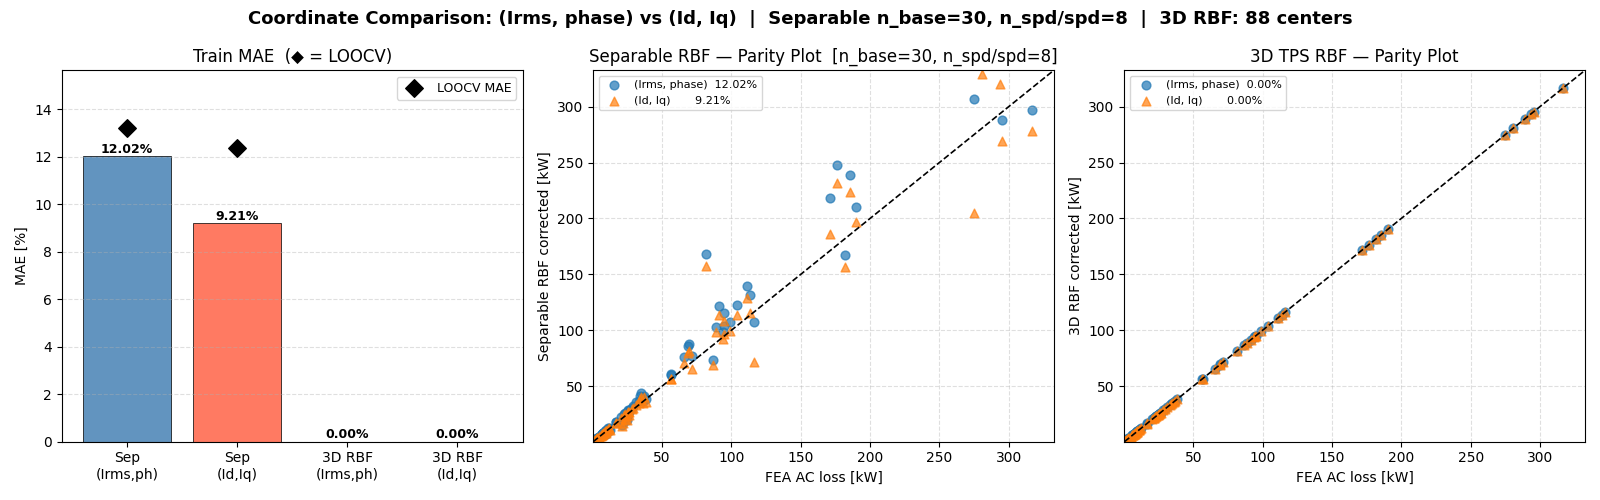

저장: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\SC\coord_comparison_SC.png


In [20]:
CUSTOM_N_BASE = 30
CUSTOM_N_SPD  = 8
CUSTOM_SEED   = 42

base_idx = np.where(np.abs(dataset.speeds_k - 2.0) < 0.1)[0]
if CUSTOM_N_BASE is not None or CUSTOM_N_SPD is not None:
    _cb = CUSTOM_N_BASE if CUSTOM_N_BASE is not None else len(base_idx)
    _cs = CUSTOM_N_SPD  if CUSTOM_N_SPD  is not None else n_spd_len
    model_sep_eval = AcLossEvaluator.rebuild_sep_model_with_subsampling(dataset, _cb, _cs, CUSTOM_SEED)
    _n_base, _n_spd = _cb, _cs
    print(f'  [CUSTOM]  Separable RBF rebuilt  →  n_base={_n_base}, n_spd/spd={_n_spd}, seed={CUSTOM_SEED}')
else:
    model_sep_eval = model_sep
    _n_base, _n_spd = n_base_len, n_spd_len
    print(f'  [DEFAULT] Using model from [5.5]  →  n_base={_n_base}, n_spd/spd={_n_spd}')

print(f'ARD  (Irms/phase): LS_I={dataset.LS_I:.1f} A, LS_P={dataset.LS_P:.2f} deg')
print(f'ARD  (Id/Iq):      LS_ID={dataset.LS_ID:.1f} A, LS_IQ={dataset.LS_IQ:.1f} A')

not_base = ~(np.abs(dataset.speeds_k - 2.0) < 0.1)
spdo = dataset.speeds_k[not_base]
afo  = dataset.af_arr[not_base]

print('\n=== 모델 빌드 중 ===')
# 1. Separable (Irms, phase)
af_sep_ip = model_sep_eval.predict(dataset.speeds_k * 1000.0, dataset.irms_arr, dataset.phase_arr)
mae_sep_ip = np.abs((dataset.h_ac_arr * af_sep_ip - dataset.f_ac_arr) / (dataset.f_ac_arr + 1e-12) * 100.0).mean()

# 2. Separable (Id, Iq)
id_base = dataset.id_arr[base_idx]
iq_base = dataset.iq_arr[base_idx]
af_base = dataset.af_arr[base_idx]
Phi_dq = np.zeros((len(base_idx), len(base_idx)))
for j in range(len(base_idx)):
    r2 = (id_base - id_base[j])**2 / dataset.LS_ID**2 + (iq_base - iq_base[j])**2 / dataset.LS_IQ**2
    Phi_dq[:, j] = r2 * np.log(np.sqrt(r2) + 1e-12)
w_dq = np.linalg.solve(Phi_dq + 1e-6 * np.eye(len(base_idx)), af_base)

def predict_g_dq(id_val, iq_val):
    id_val, iq_val = np.asarray(id_val, float), np.asarray(iq_val, float)
    id_val, iq_val = np.broadcast_arrays(id_val, iq_val)
    orig = id_val.shape
    id_v, iq_v = id_val.ravel()[:, None], iq_val.ravel()[:, None]
    r2 = (id_v - id_base)**2 / dataset.LS_ID**2 + (iq_v - iq_base)**2 / dataset.LS_IQ**2
    res = (r2 * np.log(np.sqrt(r2) + 1e-12)) @ w_dq
    return res.reshape(orig) if orig else float(res[0])

f_by_dq = {2.0: [1.0]}
for idx in range(len(spdo)):
    gv = float(predict_g_dq(dataset.id_arr[not_base][idx], dataset.iq_arr[not_base][idx]))
    f_by_dq.setdefault(spdo[idx], []).append(afo[idx] / (gv + 1e-12))
sc_dq = sorted(f_by_dq.keys())
fc_dq = [np.mean(f_by_dq[s]) for s in sc_dq]
pf_dq = np.poly1d(np.polyfit(sc_dq, fc_dq, min(2, len(sc_dq) - 1)))

af_sep_dq = pf_dq(dataset.speeds_k) * predict_g_dq(dataset.id_arr, dataset.iq_arr).ravel()
mae_sep_dq = np.abs((dataset.h_ac_arr * af_sep_dq - dataset.f_ac_arr) / (dataset.f_ac_arr + 1e-12) * 100.0).mean()

# 3. 3D TPS RBF (Irms, phase)
af_3d_ip = model_3d.predict(dataset.speeds_k * 1000.0, dataset.irms_arr, dataset.phase_arr)
mae_3d_ip = np.abs((dataset.h_ac_arr * af_3d_ip - dataset.f_ac_arr) / (dataset.f_ac_arr + 1e-12) * 100.0).mean()

# 4. 3D TPS RBF (Id, Iq)
Phi_3d_dq = np.zeros((len(dataset), len(dataset)))
for j in range(len(dataset)):
    r2 = (dataset.speeds_k - dataset.speeds_k[j])**2 / dataset.LS_S**2 + \
         (dataset.id_arr - dataset.id_arr[j])**2 / dataset.LS_ID**2 + \
         (dataset.iq_arr - dataset.iq_arr[j])**2 / dataset.LS_IQ**2
    Phi_3d_dq[:, j] = r2 * np.log(np.sqrt(r2) + 1e-12)
w_3d_dq = np.linalg.solve(Phi_3d_dq + 1e-6 * np.eye(len(dataset)), dataset.af_arr)

def predict_3d_dq(s_val, id_val, iq_val):
    s_val = np.asarray(s_val, float) / 1000.0
    id_val, iq_val = np.asarray(id_val, float), np.asarray(iq_val, float)
    s_val, id_val, iq_val = np.broadcast_arrays(s_val, id_val, iq_val)
    orig = s_val.shape
    sv, id_v, iq_v = s_val.ravel()[:, None], id_val.ravel()[:, None], iq_val.ravel()[:, None]
    r2 = (sv - dataset.speeds_k)**2 / dataset.LS_S**2 + \
         (id_v - dataset.id_arr)**2 / dataset.LS_ID**2 + \
         (iq_v - dataset.iq_arr)**2 / dataset.LS_IQ**2
    res = (r2 * np.log(np.sqrt(r2) + 1e-12)) @ w_3d_dq
    return res.reshape(orig) if orig else float(res[0])

af_3d_dq = predict_3d_dq(dataset.speeds_k * 1000.0, dataset.id_arr, dataset.iq_arr).ravel()
mae_3d_dq = np.abs((dataset.h_ac_arr * af_3d_dq - dataset.f_ac_arr) / (dataset.f_ac_arr + 1e-12) * 100.0).mean()

print(f'  Separable  (Irms, phase): Train MAE = {mae_sep_ip:.3f}%')
print(f'  Separable  (Id,   Iq  ): Train MAE = {mae_sep_dq:.3f}%')
print(f'  3D TPS RBF (Irms, phase): Train MAE = {mae_3d_ip:.3f}%')
print(f'  3D TPS RBF (Id,   Iq  ): Train MAE = {mae_3d_dq:.3f}%')

print('\n  LOOCV 계산 중 (Separable 2가지)...')
cv_sep_ip = AcLossEvaluator.compute_loocv_separable(dataset, _n_base, _n_spd)

# LOOCV for Separable (Id, Iq)
loocv_dq_errors = []
spd_grps = {s: np.where(np.abs(dataset.speeds_k - s) < 0.1)[0] for s in other_speeds}
for i in range(len(dataset)):
    base_tr_idx = [idx for idx in base_idx if idx != i]
    id_base_tr = dataset.id_arr[base_tr_idx]
    iq_base_tr = dataset.iq_arr[base_tr_idx]
    af_base_tr = dataset.af_arr[base_tr_idx]
    
    Phi_dq_tr = np.zeros((len(base_tr_idx), len(base_tr_idx)))
    for j in range(len(base_tr_idx)):
        r2 = (id_base_tr - id_base_tr[j])**2 / dataset.LS_ID**2 + (iq_base_tr - iq_base_tr[j])**2 / dataset.LS_IQ**2
        Phi_dq_tr[:, j] = r2 * np.log(np.sqrt(r2) + 1e-12)
    try:
        w_g_dq_tr = np.linalg.solve(Phi_dq_tr + 1e-6 * np.eye(len(base_tr_idx)), af_base_tr)
    except np.linalg.LinAlgError:
        continue
        
    def predict_g_dq_tr(id_val, iq_val):
        id_v, iq_v = np.asarray(id_val, float).ravel()[:, None], np.asarray(iq_val, float).ravel()[:, None]
        r2 = (id_v - id_base_tr)**2 / dataset.LS_ID**2 + (iq_v - iq_base_tr)**2 / dataset.LS_IQ**2
        return (r2 * np.log(np.sqrt(r2) + 1e-12)) @ w_g_dq_tr
        
    f_by_dq_tr = {2.0: [1.0]}
    for spd in other_speeds:
        grp = spd_grps[spd]
        grp_tr = [idx for idx in grp if idx != i]
        rng = np.random.RandomState(42)
        n_sel = min(_n_spd, len(grp_tr))
        if n_sel > 0:
            for idx in rng.choice(grp_tr, n_sel, replace=False):
                gv = float(predict_g_dq_tr(dataset.id_arr[idx], dataset.iq_arr[idx])[0])
                f_by_dq_tr.setdefault(spd, []).append(dataset.af_arr[idx] / (gv + 1e-12))
    sc = sorted(f_by_dq_tr.keys())
    if len(sc) < 2:
        continue
    fc = [np.mean(f_by_dq_tr[s]) for s in sc]
    pf_dq_tr = np.poly1d(np.polyfit(sc, fc, min(2, len(sc) - 1)))
    
    gv_i = float(predict_g_dq_tr(dataset.id_arr[i], dataset.iq_arr[i])[0])
    fv_i = pf_dq_tr(dataset.speeds_k[i])
    af_i = fv_i * gv_i
    corr_val = dataset.h_ac_arr[i] * af_i
    loocv_dq_errors.append(abs((corr_val - dataset.f_ac_arr[i]) / (dataset.f_ac_arr[i] + 1e-12) * 100.0))
    
cv_sep_dq = float(np.mean(loocv_dq_errors)) if loocv_dq_errors else np.nan

print(f'  Separable [n_base={_n_base}, n_spd/spd={_n_spd}] LOOCV  (Irms, phase): {cv_sep_ip:.3f}%')
print(f'  Separable [n_base={_n_base}, n_spd/spd={_n_spd}] LOOCV  (Id, Iq):       {cv_sep_dq:.3f}%')

AcLossPlotter.plot_coordinate_comparison(
    dataset, mae_sep_ip, mae_sep_dq, mae_3d_ip, mae_3d_dq,
    cv_sep_ip, cv_sep_dq, af_sep_ip, af_sep_dq, af_3d_ip, af_3d_dq,
    _n_base, _n_spd, out_dir / f'coord_comparison_{MODEL_SCALE}.png'
)

# [6.6] Method B — 3D Surface Visualization: AF(Id, Iq) per Speed

d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:590: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:590: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:590: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:590: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:590: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPl

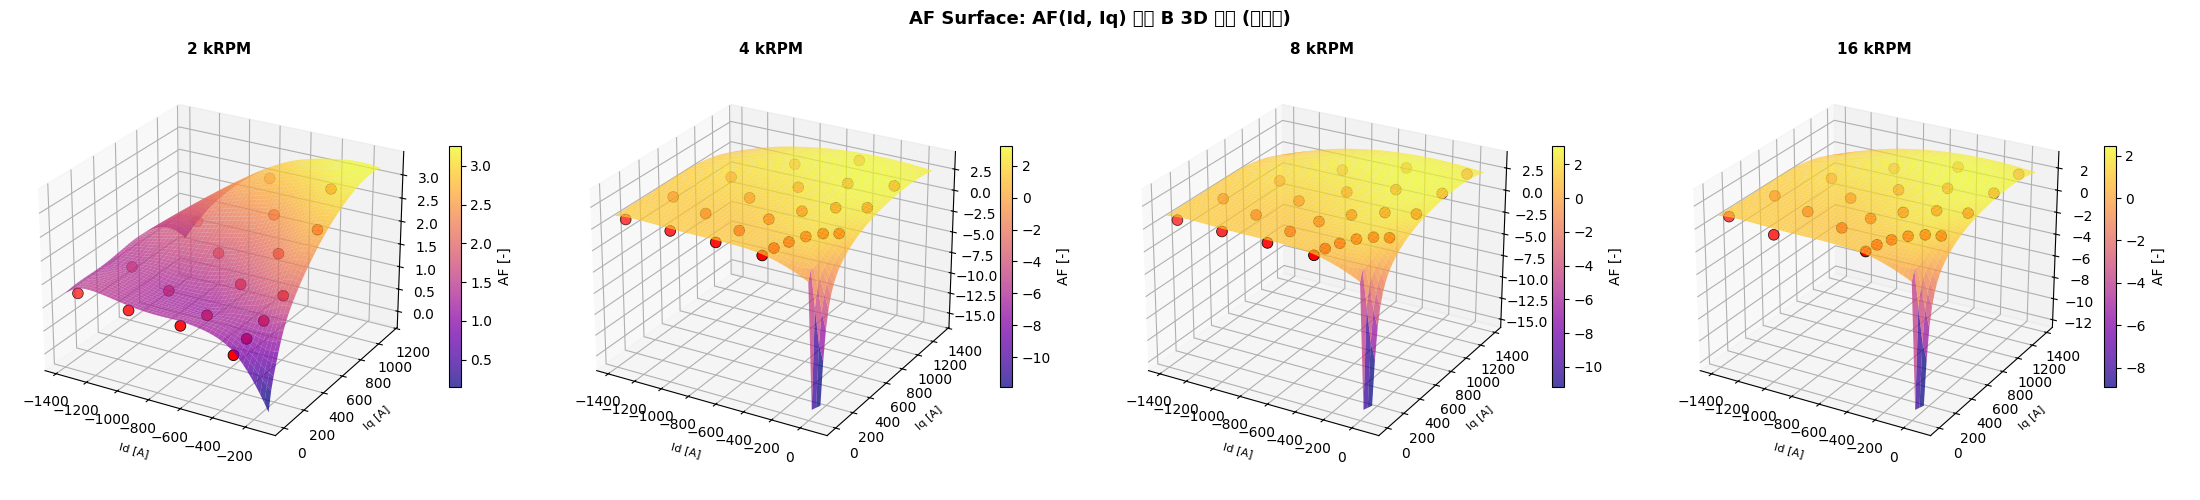

저장 완료: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\SC\AF_3D_surface.png


In [21]:
AcLossPlotter.plot_3d_surface(dataset, model_sep, out_dir / "AF_3D_surface.png")

# [7] Final Model Validation & Comparison

  f( 2000 RPM): n=1  mean=1.0000  range=[1.0000, 1.0000]
  f( 4000 RPM): n=8  mean=0.9460  range=[0.8300, 1.3744]
  f( 8000 RPM): n=8  mean=0.8205  range=[0.6601, 1.0845]
  f(16000 RPM): n=8  mean=0.7862  range=[0.3807, 1.0886]
  [CUSTOM]  Separable RBF rebuilt  →  n_base=30, n_spd/spd=8, seed=42
=== RBF 보정 오차 검증 및 비교: 3D RBF vs Separable vs FullFEA (SC) ===

  [Separable RBF config]  n_base=30  |  n_spd/spd=8
  3D TPS RBF: 88 centers (all points)

  LOOCV 계산 중 (약 1.5초 소요)... 
=== RBF 보정 오차 최종 비교 결과 ===
  1) Hybrid (보정 전):        Train MAE=29.58% | MaxAE=110.81%
  2) 3D TPS RBF:             Train MAE=0.00% | MaxAE=0.00% | LOOCV MAE=4.69%
  3) Separable [n_base=30, n_spd/spd=8]:   Train MAE=12.02% | MaxAE=106.29% | LOOCV MAE=13.19%


d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:653: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:653: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:653: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:653: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:653: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter

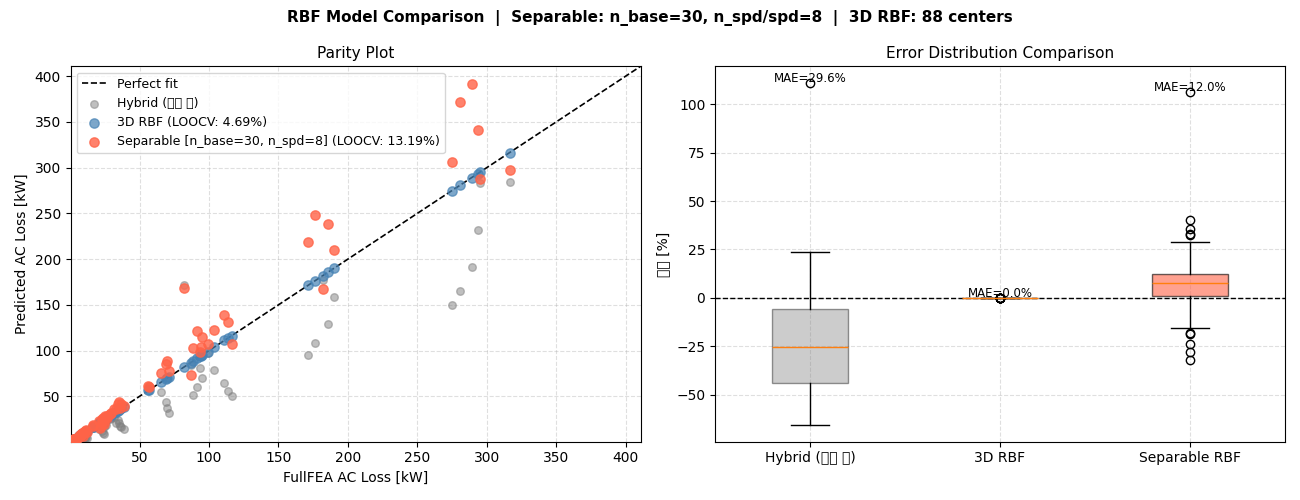

d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:807: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:807: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:807: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


그림 저장 완료: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\SC\RBF_correction_validation_SC.png
--- Matplotlib Backend Config ---
  [Selection] 'auto' -> 'widget'

  대화형 4-Way 비교 플롯 로딩...


d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:807: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:807: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:807: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:807: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotter.py:807: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\jeet_acloss_rbf\AcLossPlotte

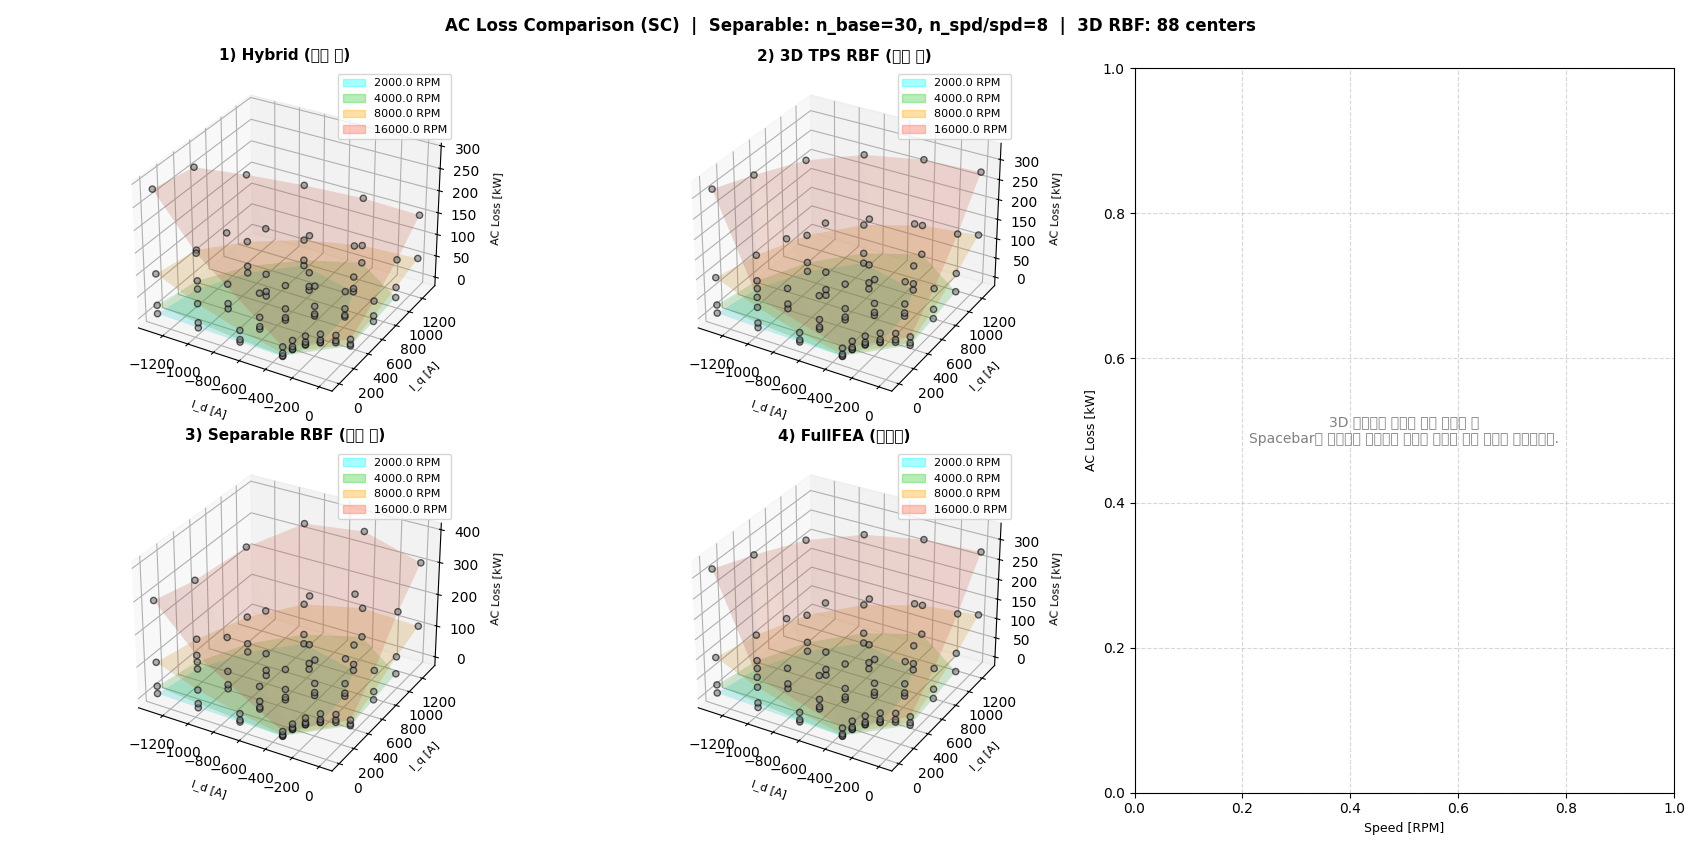

In [25]:
CUSTOM_N_BASE = 30
CUSTOM_N_SPD  = 8
CUSTOM_SEED   = 42

if CUSTOM_N_BASE is not None or CUSTOM_N_SPD is not None:
    _cb = CUSTOM_N_BASE if CUSTOM_N_BASE is not None else len(base_idx)
    _cs = CUSTOM_N_SPD  if CUSTOM_N_SPD  is not None else n_spd_len
    model_sep_eval = AcLossEvaluator.rebuild_sep_model_with_subsampling(dataset, _cb, _cs, CUSTOM_SEED)
    _n_base, _n_spd = _cb, _cs
    print(f'  [CUSTOM]  Separable RBF rebuilt  →  n_base={_n_base}, n_spd/spd={_n_spd}, seed={CUSTOM_SEED}')
else:
    model_sep_eval = model_sep
    _n_base, _n_spd = n_base_len, n_spd_len
    print(f'  [DEFAULT] Using model from [5.5]  →  n_base={_n_base}, n_spd/spd={_n_spd}')

print(f"=== RBF 보정 오차 검증 및 비교: 3D RBF vs Separable vs FullFEA ({MODEL_SCALE}) ===\n")
print(f"  [Separable RBF config]  n_base={_n_base}  |  n_spd/spd={_n_spd}")
print(f"  3D TPS RBF: {len(dataset)} centers (all points)\n")

ea, e3, es = AcLossEvaluator.evaluate_errors(dataset, model_3d, model_sep_eval)

print("  LOOCV 계산 중 (약 1.5초 소요)... ")
mae_loocv_3d = AcLossEvaluator.compute_loocv_3d(dataset)
mae_loocv_sep = AcLossEvaluator.compute_loocv_separable(dataset, _n_base, _n_spd)

print("=== RBF 보정 오차 최종 비교 결과 ===")
print(f"  1) Hybrid (보정 전):        Train MAE={np.abs(ea).mean():.2f}% | MaxAE={np.abs(ea).max():.2f}%")
print(f"  2) 3D TPS RBF:             Train MAE={np.abs(e3).mean():.2f}% | MaxAE={np.abs(e3).max():.2f}% | LOOCV MAE={mae_loocv_3d:.2f}%")
print(f"  3) Separable [n_base={_n_base}, n_spd/spd={_n_spd}]:   Train MAE={np.abs(es).mean():.2f}% | MaxAE={np.abs(es).max():.2f}% | LOOCV MAE={mae_loocv_sep:.2f}%")

AcLossPlotter.plot_rbf_correction_validation(
    dataset, ea, e3, es, mae_loocv_3d, mae_loocv_sep,
    _n_base, _n_spd, model_3d, model_sep_eval,
    out_dir / f"RBF_correction_validation_{MODEL_SCALE}.png"
)

# Export JSON configuration
export = {
    "model_type": f"RBF_{MODEL_SCALE}",
    "3D_model": {
        "model": "3D_TPS_RBF",
        "n_centers": int(len(dataset)),
        "weights": model_3d.weights.tolist(),
        "validation": {
            "Train_MAE_pct": float(np.abs(e3).mean()),
            "LOOCV_MAE_pct": float(mae_loocv_3d),
        },
        "mcad_formula": model_3d.mcad_formula
    },
    "separable_model": {
        "model": "Separable_1D_2D_RBF",
        "n_base_centers": int(_n_base),
        "base_weights": model_sep_eval.w_g.tolist(),
        "speed_poly_coeffs": model_sep_eval.p_coeffs.tolist(),
        "validation": {
            "Train_MAE_pct": float(np.abs(es).mean()),
            "LOOCV_MAE_pct": float(mae_loocv_sep),
        },
        "mcad_formula": model_sep_eval.mcad_formula
    },
    "mcad_formula_full": model_3d.mcad_formula,
    "mcad_formula_reduced_30": model_sep_eval.mcad_formula,
    "mcad_formula_top20": model_sep_eval.mcad_formula,
    "length_scales": {"LS_S_kRPM": float(dataset.LS_S), "LS_I_A": float(dataset.LS_I), "LS_P_deg": float(dataset.LS_P)},
    "af_points": [
        {
            "speed_rpm": float(p.speed_rpm),
            "speed_kRPM": float(p.speed_kRPM),
            "current_rms": float(p.current_rms),
            "phase_deg": float(p.phase_deg),
            "id_A": float(p.id_A),
            "iq_A": float(p.iq_A),
            "hybrid_ac_kW": float(p.hybrid_ac_kW),
            "fea_ac_kW": float(p.fea_ac_kW),
            "AF": float(p.AF),
        } for p in dataset.points
    ]
}
# with open(rbf_model_path, "w", encoding="utf-8") as f:
    # json.dump(export, f, ensure_ascii=False, indent=2)
# print(f"JSON 모델 저장 완료: {rbf_model_path}")

# 4-Way comparison interactive plot
AcLossPlotter.configure_matplotlib_backend('auto')
print("\n  대화형 4-Way 비교 플롯 로딩...")
AcLossPlotter.plot_interactive_4way_comparison(dataset, model_3d, model_sep_eval, MODEL_SCALE, _n_base, _n_spd)